<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 1</center></h1>

- Nome completo: Hélio Henrique de Souza
- [Link para vídeo](<LINK_VIDEO>)
- [Link para git](<https://github.com/HezaH/Machine_Learning>)

# Import Libs

In [26]:
import os
import time
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, 
    median_absolute_error, mean_squared_log_error, explained_variance_score,
    confusion_matrix, classification_report, accuracy_score,
    f1_score, balanced_accuracy_score, average_precision_score
)
from pathlib import Path
from sklearn.decomposition import PCA
from IPython.display import HTML, IFrame

# Main functions

In [ ]:
def show_confusion( y_true, y_pred, labels, name_fig , title="Matriz de Confusão", plot_heatmap=True, cmap="Blues", figsize=(6, 5), ):
    """
    Exibe a matriz de confusão com rótulos nas linhas (reais)
    e colunas (preditos) na ordem especificada por `labels`.

    Parâmetros
    ----------
    y_true : array-like
        Rótulos reais.
    y_pred : array-like
        Rótulos preditos.
    labels : list
        Ordem desejada das classes (ex.: ['NONE', 'WEAK', 'MODERATE', 'STRONG']).
    title : str
        Título mostrado antes da tabela / heatmap.
    plot_heatmap : bool
        Se True, desenha também um heatmap usando seaborn.
    cmap : str
        Mapa de cores para o heatmap.
    figsize : tuple
        Tamanho da figura do heatmap.
    """
    # 1. Matriz numérica
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 2. DataFrame bonito para print
    df_cm = pd.DataFrame(
        cm,
        index=[f"REAL → {lbl}" for lbl in labels],
        columns=[f"PRED → {lbl}" for lbl in labels],
    )

    # 3. Print “cru” no console
    print(f"\n{title}")
    print(df_cm)

    # 4. Heatmap opcional
    if plot_heatmap:
        plt.figure(figsize=figsize)
        sns.heatmap(
            df_cm,
            annot=True,
            fmt="d",
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="0.9",
        )
        plt.title(title, fontweight="bold")
        plt.ylabel("Classe Real")
        plt.xlabel("Classe Predita")
        plt.tight_layout()
        try:
            plt.savefig(name_fig, dpi=300, bbox_inches='tight')
        except:
            plt.show()
        plt.close()

def predict_ordinal(df, classifiers, features):
    preds = []
    for clf in classifiers:
        # Supondo que você queira as probabilidades da classe 1 para cada limiar
        pred = clf.predict_proba(df[features])[:, 1]
        preds.append(pred)
    
    preds = np.array(preds)  # shape: (n_threshold, n_samples)
    # Calcula as probabilidades das k classes:
    # Para a primeira classe:
    prob_class0 = 1 - preds[0]
    prob_classes = [prob_class0]
    
    # Para as classes intermediárias:
    for i in range(1, preds.shape[0]):
        # A probabilidade da classe i é a diferença entre a probabilidade da classe i-1 e a classe i
        #preds[i-1] = probabilidade da classe i-1
        #preds[i] = probabilidade da classe i
        prob = preds[i-1] - preds[i]
        prob_classes.append(prob)
    
    # Para a última classe:
    prob_class_last = preds[-1]
    prob_classes.append(prob_class_last)
    
    # Transforma em array: shape (k, n_samples)
    prob_classes = np.array(prob_classes)
    
    # Predição final: índice da classe com maior probabilidade
    pred_idx = np.argmax(prob_classes, axis=0)
    
    # Cria um dicionário inverso para mapear o código ordinal para a categoria
    mapping_inv = {v: k for k, v in choices.items()}
    pred_labels = [mapping_inv[i] for i in pred_idx]
    return pred_labels, prob_classes

def change_cathegory(df, choices):
    """
    Transforma a variável 'target' em uma classificação ordinal:
      - Cria a coluna "categoria", baseada em condições do valor contínuo;
      - Mapeia para "cat_code" usando o dicionário de escolhas, mas apenas com os rótulos presentes no dataframe;
      - Cria as colunas binárias T_1, T_2, ... T_(k-1), onde k é o número de categorias observadas.
    """
    # Definir as condições para os intervalos
    conditions = [
        (df["target"] == 0),
        ((df["target"] > 0) & (df["target"] <= 5)),
        ((df["target"] > 5) & (df["target"] <= 25)),
        (df["target"] > 25)
        # ((df["target"] > 25) & (df["target"] <= 50)),
        # (df["target"] > 50)
    ]
    
    # Aplica o np.select usando todas as categorias do dicionário base
    df["categoria"] = np.select(conditions, list(choices.keys()), default=np.nan)
    
    # Filtra as categorias que de fato aparecem no dataframe, mantendo a ordem definida em choices
    present_cats = [cat for cat in choices.keys() if (df["categoria"] == cat).any()]
    
    # Cria um novo mapeamento somente para as categorias presentes
    new_choices = {cat: i for i, cat in enumerate(present_cats)}
    
    # Mapeia os rótulos que foram de fato usados para códigos numéricos
    df["cat_code"] = df["categoria"].map(new_choices)
    
    # Número de colunas binárias a serem criadas (k - 1), onde k é o número de categorias presentes
    n = len(new_choices) - 1  
    for i in range(n):
        df[f'T_{i+1}'] = (df["cat_code"] > i).astype(int)
        
    return df, new_choices


# (1) Enngenharia de Features

Importando o modelo, definindo as colunas 

In [34]:
# Inicia a medição do tempo
start_time = time.time()
out_dir = Path("figures")
out_dir.mkdir(exist_ok=True)

# Carrega o dataset
try:
    df_diamonds = pd.read_csv('diamonds.csv')
except FileNotFoundError:
    out_dir = os.path.dirname(os.path.realpath(__file__))
    current_dir = out_dir
    df_diamonds = pd.read_csv(os.path.join(current_dir, 'diamonds.csv'))

Tratamento dos dados

In [35]:

# Para treinar um modelo que prediz z, selecione apenas os registros com z > 0 (valores válidos)
df_diamonds = df_diamonds[~df_diamonds.index.isin(df_diamonds[df_diamonds[['x', 'y', 'z']].eq(0).sum(axis=1) >= 2].index)].copy()

df_valid = df_diamonds[df_diamonds['z'] > 0].copy()
df_invalid = df_diamonds[df_diamonds['z'] == 0].copy()


Pipeline de predição de z vazios

In [36]:

# Defina as features originais que queremos usar. Atenção: não use features derivadas que contenham z (como volume).
# Neste exemplo, utilizaremos as medidas originais e informações categóricas.
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y']
target = 'z'

X = df_valid[features]
y = df_valid[target]

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defina os nomes das colunas numéricas e categóricas
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y']
categorical_preproc = ['cut', 'color', 'clarity']

# Cria o pré-processador: escalona os numéricos e codifica as categorias (usando OneHotEncoder para evitar assumir ordens pré-definidas)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(), categorical_preproc )
])

# Instancia o modelo. Aqui usamos regressão linear simples; você pode testar outros modelos, como RandomForestRegressor.
model = LinearRegression()

# Monta o pipeline de pré-processamento e modelo
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline
pipeline_model.fit(X_train, y_train)

# Faz a predição no conjunto de teste e avalia o desempenho
y_pred = pipeline_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE para predição de z: {rmse:.4f}")


RMSE para predição de z: 0.2764


Criação de correlacoes

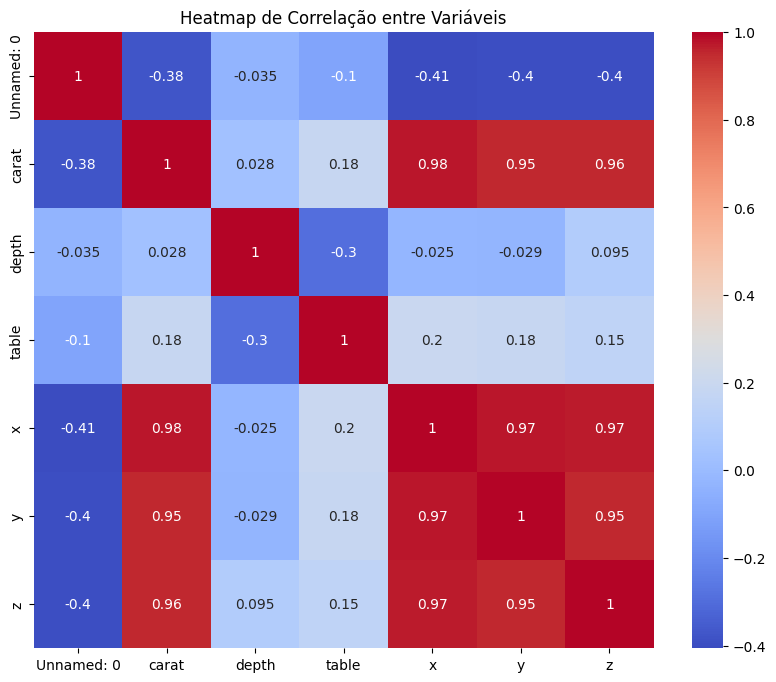

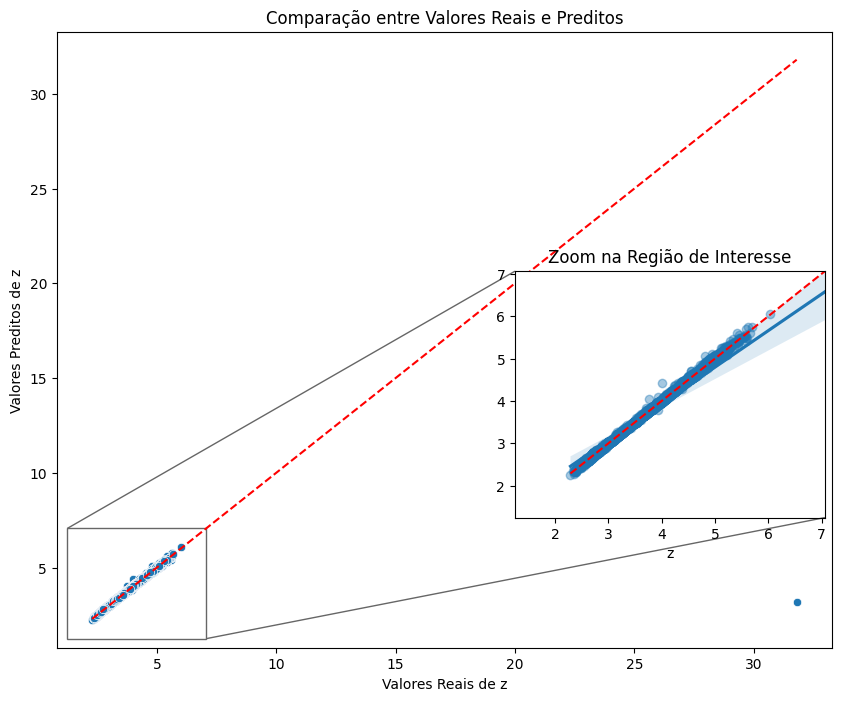

In [37]:

# Gráfico 2: Heatmap de Correlação entre as features numéricas
cols = list(df_diamonds.columns)
# Definir as features categóricas e a variável alvo

target_column = 'price'
# Para o heatmap, iremos usar apenas as colunas numéricas (excluindo as categóricas e a target)
numeric_features = [col for col in cols if col not in categorical_preproc + [target_column]]
corr_matrix = df_diamonds[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap de Correlação entre Variáveis")
try:
    plt.savefig(os.path.join(out_dir, "figures", "Heatmap.png"), dpi=300, bbox_inches='tight')
except:
    plt.show()
plt.close()

# Gráfico 1: Relação entre Volume e Preço
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred)
ax.set_title("Comparação entre Valores Reais e Preditos")
ax.set_xlabel("Valores Reais de z")
ax.set_ylabel("Valores Preditos de z")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Linha de Igualdade')
# Cria um inset (subgráfico) com zoom na região desejada
axins = inset_axes(ax, width="40%", height="40%", loc='lower right',
                   bbox_to_anchor=(0, 0.2, 1, 1),
                   bbox_transform=ax.transAxes)

sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.4}, ax=axins)
axins.set_xlim(min(y_test.min(), y_pred.min()) - 1, min(y_test.max(), y_pred.max()) + 1)         # Limita o eixo x do inset
axins.set_ylim(min(y_test.min(), y_pred.min()) - 1, min(y_test.max(), y_pred.max()) + 1)       # Limita o eixo y do inset
axins.set_title("Zoom na Região de Interesse")
axins.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Linha de Igualdade')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
try:
    plt.savefig(os.path.join(out_dir, "figures", "value_price.png"), dpi=300, bbox_inches='tight')
except:
    plt.show()
plt.close()  # Fecha o gráfico atual



Previsão de z vazios

In [38]:
# Se houver registros com z igual a 0, prevê os valores de z para esses registros.
if not df_invalid.empty:
    X_invalid = df_invalid[features]
    z_pred = pipeline_model.predict(X_invalid)
    
    # Atualiza a coluna z dos registros com z = 0 no DataFrame original
    df_diamonds.loc[df_diamonds['z'] == 0, 'z'] = abs(z_pred)
    print("Valores de z imputados para registros com z == 0.")

# Visualiza as primeiras linhas do DataFrame atualizado
print(df_diamonds.head())

Valores de z imputados para registros com z == 0.
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


Criação de features

In [39]:

# Engenharia de features: Adiciona volume e outras derivadas
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

## Calcula quartis
Q1 = df_diamonds['volume'].quantile(0.25)  # Primeiro quartil (25%)
Q3 = df_diamonds['volume'].quantile(0.75)  # Terceiro quartil (75%)
IQR = Q3 - Q1  # Intervalo interquartil

# Define limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra valores dentro do intervalo aceitável
df_diamonds = df_diamonds[(df_diamonds['volume'] >= limite_inferior) & (df_diamonds['volume'] <= limite_superior)]

df_diamonds["price_per_carat"] = df_diamonds["price"] / df_diamonds["carat"]
df_diamonds["price_per_volume"] = df_diamonds["price"] / df_diamonds["volume"]

df_diamonds["ratio_x_y"] = df_diamonds["x"] / df_diamonds["y"]
df_diamonds["ratio_x_z"] = df_diamonds["x"] / df_diamonds["z"]
df_diamonds["ratio_y_z"] = df_diamonds["y"] / df_diamonds["z"]

df_diamonds["log_price"] = np.log(df_diamonds["price"])

# Remove a coluna indesejada (se existir) e reseta o índice
if 'Unnamed: 0' in df_diamonds.columns:
    df_diamonds = df_diamonds.drop(columns='Unnamed: 0').reset_index(drop=True)

Geração de representações graficas

In [ ]:

# Criando o gráfico interativo
fig = px.scatter(df_diamonds, x="volume", y="price", color="cut",
                 title="Relação entre Volume e Preço do Diamante")

# Exportando para HTML
try:
    fig.write_html(os.path.join(out_dir, "figures", "diamantes_interativo.html"))
except:
    fig.show()

In [ ]:
# -----------------------------------------------------------
# 1. PREÇO  ×  PRICE-PER-CARAT   (cores = CUT)
# -----------------------------------------------------------
fig = px.scatter(
    df_diamonds,
    x="price_per_carat",
    y="price",
    color="cut",
    hover_data=["carat", "color", "clarity"],
    title="Preço vs. Preço por Quilate (CUT)",
    labels={
        "price_per_carat": "Preço / Quilate",
        "price": "price",
        "cut": "Cut"
    },
)
fig.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig.write_html(os.path.join(out_dir, "figures", "price_vs_price_per_carat_cut.html"), include_plotlyjs="cdn")
except:
    fig.show()

In [ ]:


# -----------------------------------------------------------
# 2. PREÇO  ×  PRICE-PER-VOLUME  (cores = CLARITY)
# -----------------------------------------------------------
fig_volume = px.scatter(
    df_diamonds,
    x="price_per_volume",
    y="price",
    color="clarity",
    hover_data=["volume", "color", "cut"],
    title="Preço vs. Preço por Volume (CLARITY)",
    labels={
        "price_per_volume": "Preço / Volume",
        "price": "price",
        "clarity": "Clarity"
    },
)
fig_volume.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig_volume.write_html(os.path.join(out_dir, "figures", "price_vs_price_per_volume_clarity.html"), include_plotlyjs="cdn")
except:
    fig_volume.show()


In [ ]:

# -----------------------------------------------------------
# 3. EXTRA (opcional): RELAÇÃO ENTRE RÁCIOS DE LADOS E PREÇO
# -----------------------------------------------------------
fig_ratio = px.scatter(
    df_diamonds,
    x="ratio_x_y",
    y="price",
    color="color",
    hover_data=["ratio_x_z", "ratio_y_z", "cut", "clarity"],
    title="Preço vs. Proporção x/y (COLOR)",
    labels={
        "ratio_x_y": "x / y",
        "price": "price",
        "color": "Color"
    },
)
fig_ratio.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig_ratio.write_html(os.path.join(out_dir, "figures", "price_vs_ratio_xy_color.html"), include_plotlyjs="cdn")
except:
    fig_ratio.show()

Segunda previsão, com novas features:

In [40]:

# Separando as variáveis preditoras e a variável alvo para modelagem
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria o pré-processador com codificação ordinal
# Define as ordens para as variáveis categóricas
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Como X não possui a coluna target, definimos as features numéricas para o pré-processador:

numeric_preproc = [col for col in X.columns if col not in categorical_preproc]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_preproc),
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_preproc)
])

# Instancia o modelo KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)

# Monta o pipeline (pré-processamento + modelo)
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline usando os dados de treino
pipeline_model.fit(X_train, y_train)

# Faz a predição no conjunto de teste
y_pred = pipeline_model.predict(X_test)




Metricas de avaliação

In [42]:
# Calcula as métricas de avaliação
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
median_ae = median_absolute_error(y_test, y_pred)
msle = mean_squared_log_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("KNeighborsRegressor (n_neighbors=5)")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Median Absolute Error: {median_ae:.4f}")
print(f"MSLE: {msle:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Finaliza a medição do tempo
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTempo total de processamento: {elapsed_time:.2f} segundos")

KNeighborsRegressor (n_neighbors=5)
RMSE: 333.7172
R²: 0.9910
MAE: 194.6338
Median Absolute Error: 95.0000
MSLE: 0.0076
Explained Variance Score: 0.9910
Adjusted R²: 0.9910
MAPE: 6.30%

Tempo total de processamento: 21.08 segundos


# (2) Classificação Ordinal Multi-classes

In [51]:
# Inicia a medição do tempo
start_time = time.time()

Lendo o arquivo

In [52]:
try:
    # Load the dataset from the current directory
    with open('A652.pickle', 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
except FileNotFoundError:
    current_dir = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'A652.pickle')

    f = open(current_dir, 'rb')
    (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f) 

print(f"Shapes: {X_train.shape}, {X_test.shape}, {X_val.shape}")

Shapes: (10012, 24), (9582, 24), (2506, 24)


Aplicando a transformacao

In [53]:

target = 'target'
scoring_type = 'accuracy'  # ou 'f1', 'precision', 'recall'

# Converte os arrays para DataFrames: concatena as features e o target
df_train = pd.concat([
    pd.DataFrame(X_train),
    pd.Series(y_train.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_val = pd.concat([
    pd.DataFrame(X_val),
    pd.Series(y_val.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_test = pd.concat([
    pd.DataFrame(X_test),
    pd.Series(y_test.ravel(), name=target)
], axis=1).reset_index(drop=True)

# Dicionário base com a ordem desejada
choices = {"NONE": 0, "WEAK": 1, "MODERATE": 2, "STRONG": 3}#, "EXTREME": 4}

print(f"Categorias: {choices.keys()}")

# Aplica a transformação em cada DataFrame
df_train, new_choices_train = change_cathegory(df_train, choices)
df_val, new_choices_val   = change_cathegory(df_val, choices)
df_test, new_choices_test  = change_cathegory(df_test, choices)

Categorias: dict_keys(['NONE', 'WEAK', 'MODERATE', 'STRONG'])


Definição de features

In [54]:
# Define as features para os modelos: remove as colunas derivadas do target
n_threshold = len(new_choices_train) - 1  # k - 1, onde k é o número de categorias presentes
exclude_cols = [target, "categoria", "cat_code"] + [f'T_{i+1}' for i in range(n_threshold)]
features = [col for col in df_train.columns if col not in exclude_cols]

Modelo Ordinal

== Treinamento do Modelo Ordinal ==
Treinando modelo para T_1, equiparado a 'NONE'
Treinando modelo para T_2, equiparado a 'WEAK'
Treinando modelo para T_3, equiparado a 'MODERATE'
== Modelo Ordinal ==

Matriz de Confusão – Modelo Ordinal
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8653           96               17              3
REAL → WEAK              481          251               25              0
REAL → MODERATE           26           21                3              0
REAL → STRONG              2            3                0              1


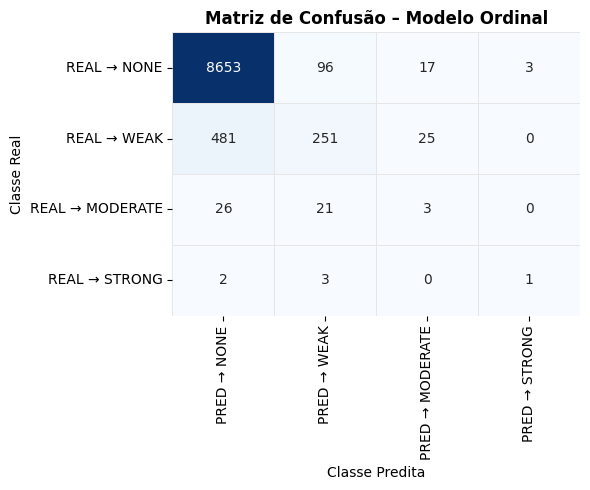


Classification Report (Ordinal):
              precision    recall  f1-score   support

        NONE       0.94      0.99      0.97      8769
        WEAK       0.68      0.33      0.45       757
    MODERATE       0.07      0.06      0.06        50
      STRONG       0.25      0.17      0.20         6

    accuracy                           0.93      9582
   macro avg       0.48      0.39      0.42      9582
weighted avg       0.92      0.93      0.92      9582



In [55]:

# ------------------------------------------------------------------
# ORDEM CANÔNICA DAS CLASSES
# ------------------------------------------------------------------
label_order  = list(choices.keys())# ['NONE','WEAK','MODERATE','STRONG']
try:
    out_dir = os.path.dirname(os.path.realpath(__file__))
except: 
    our_dir = os.getcwd()
# ------------------------------------------------------------------
# MODELO ORDINAL
# ------------------------------------------------------------------
ordinal_classifiers = []
print("== Treinamento do Modelo Ordinal ==")
for i in range(1, n_threshold + 1):
    clf = GradientBoostingClassifier(random_state=42)
    print(f"Treinando modelo para T_{i}, equiparado a '{label_order[i-1]}'")
    clf.fit(df_train[features], df_train[f'T_{i}'])
    ordinal_classifiers.append(clf)

ord_pred_labels, ord_pred_numbers = predict_ordinal(df_test, ordinal_classifiers, features)

print("== Modelo Ordinal ==")
show_confusion( df_test["categoria"], ord_pred_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_ordinal.png"), labels=label_order, title="Matriz de Confusão – Modelo Ordinal", )
print("\nClassification Report (Ordinal):")
print(classification_report(df_test["categoria"], ord_pred_labels,labels= label_order,target_names= label_order,zero_division=0))


Modelo Nominal


== Treinamento do Modelo Nominal ==
== Modelo Nominal ==

Matriz de Confusão – Modelo Nominal
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8678           86                2              3
REAL → WEAK              507          234               16              0
REAL → MODERATE           25           23                2              0
REAL → STRONG              3            2                0              1


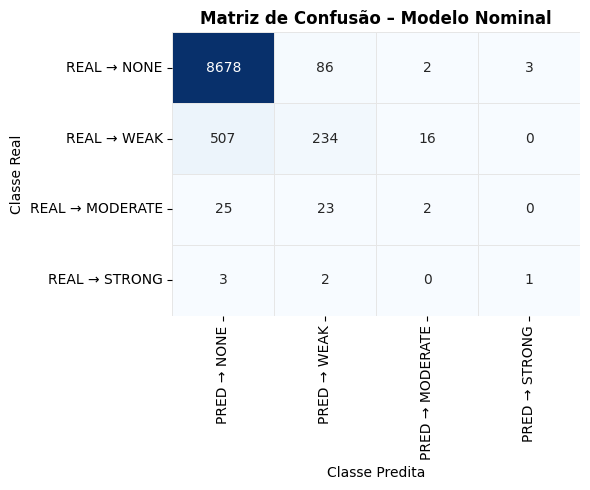


Classification Report (Nominal):
              precision    recall  f1-score   support

        NONE       0.94      0.99      0.97      8769
        WEAK       0.68      0.31      0.42       757
    MODERATE       0.10      0.04      0.06        50
      STRONG       0.25      0.17      0.20         6

    accuracy                           0.93      9582
   macro avg       0.49      0.38      0.41      9582
weighted avg       0.92      0.93      0.92      9582

Execution time: 41.41 seconds


In [56]:

# ------------------------------------------------------------------
# MODELO NOMINAL
# ------------------------------------------------------------------
print("\n== Treinamento do Modelo Nominal ==")
le = LabelEncoder()
df_train["cat_nominal"] = le.fit_transform(df_train["categoria"])
df_val["cat_nominal"]   = le.transform(df_val["categoria"])
df_test["cat_nominal"]  = le.transform(df_test["categoria"])

nominal_clf = GradientBoostingClassifier(random_state=42).fit(df_train[features], df_train["cat_nominal"])
nom_pred_labels = le.inverse_transform(nominal_clf.predict(df_test[features]))

print("== Modelo Nominal ==")
show_confusion(df_test["categoria"], nom_pred_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_norminal.png"), labels=label_order, title="Matriz de Confusão – Modelo Nominal", )
print("\nClassification Report (Nominal):")
print(classification_report( df_test["categoria"], nom_pred_labels, labels = label_order, target_names= label_order, zero_division=0))


# Tempo total de execução
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")


# (4)  Redução de dimensionalidade

In [ ]:
# Start time measurement
start_time = time.time()

Lendo o arquivo

In [57]:
try:
    # Load the dataset from the current directory
    with open('A652.pickle', 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
except FileNotFoundError:
    current_dir = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'A652.pickle')

    f = open(current_dir, 'rb')
    (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f) 

print(f"Shapes: {X_train.shape}, {X_test.shape}, {X_val.shape}")


Shapes: (10012, 24), (9582, 24), (2506, 24)


Aplicando a tranformação

In [58]:

target = 'target'

# Converte os arrays para DataFrames: concatena as features e o target
df_train = pd.concat([
    pd.DataFrame(X_train),
    pd.Series(y_train.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_val = pd.concat([
    pd.DataFrame(X_val),
    pd.Series(y_val.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_test = pd.concat([
    pd.DataFrame(X_test),
    pd.Series(y_test.ravel(), name=target)
], axis=1).reset_index(drop=True)

# Dicionário base com a ordem desejada para o target
choices = {"NONE": 0, "WEAK": 1, "MODERATE": 2, "STRONG": 3}
label_order  = list(choices.keys())# ['NONE','WEAK','MODERATE','STRONG']
print(f"Categorias: {choices.keys()}")

# Aplica a transformação em cada DataFrame (gera também o mapeamento dinâmico new_choices)
df_train, new_choices_train = change_cathegory(df_train, choices)
df_val, new_choices_val   = change_cathegory(df_val, choices)
df_test, new_choices_test = change_cathegory(df_test, choices)

Categorias: dict_keys(['NONE', 'WEAK', 'MODERATE', 'STRONG'])


Definicao de feature

In [60]:
# Define as features para os modelos: remove as colunas derivadas do target
n_threshold = len(new_choices_train) - 1  # k - 1, onde k é o número de categorias presentes
exclude_cols = [target, "categoria", "cat_code"] + [f'T_{i+1}' for i in range(n_threshold)]
features = [col for col in df_train.columns if col not in exclude_cols]
print(f"Total de features originais usadas: {len(features)}")

Total de features originais usadas: 24


Hiperparametros

In [61]:
# -------------  hiper-parâmetros --------------------------
k_candidates  = range(2, min(20, len(features)) + 1)  # 2 … 20  (ou 2 … |features|)
metric_focus  = "macro_f1"      # métrica que decide o “winner”
verbose       = True

Target nominal

In [62]:
# =========================================================
# 1.  TARGET NOMINAL  →  números
# =========================================================
le = LabelEncoder()
df_train["cat_nominal"] = le.fit_transform(df_train["categoria"])
df_val  ["cat_nominal"] = le.transform(df_val ["categoria"])
classes_int  = np.arange(len(le.classes_))          # [0, 1, 2, 3]

Aplicacao do PCA

In [ ]:

# =========================================================
# 2.  LOOP SOBRE k  (PCA)  +  MÉTRICAS ROBUSTAS
# =========================================================
results = {}
best_k  = None
best_score = -np.inf

for k in k_candidates:
    # ---- 2.1 PCA ----------------------------------------
    pca = PCA(n_components=k, random_state=42)
    X_train_pca = pca.fit_transform(df_train[features])
    X_val_pca   = pca.transform(df_val[features])

    # ---- 2.2 Modelo -------------------------------------
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train_pca, df_train["cat_nominal"])

    # ---- 2.3 Predições & Probabilidades -----------------
    y_val_pred      = clf.predict(X_val_pca)
    y_val_probas    = clf.predict_proba(X_val_pca)

    # ---- 2.4 Métricas “amigas da minoria” ---------------
    macro_f1  = f1_score(
        df_val["cat_nominal"], y_val_pred, average="macro", zero_division=0
    )
    bal_acc   = balanced_accuracy_score(df_val["cat_nominal"], y_val_pred)

    # AUPRC macro (Precisão-Recall) – sensível ao desequilíbrio
    y_val_bin     = label_binarize(df_val["cat_nominal"], classes=classes_int)
    auprc_macro   = average_precision_score(
        y_val_bin, y_val_probas, average="macro"
    )

    results[k] = {
        "macro_f1":  macro_f1,
        "bal_acc":   bal_acc,
        "auprc":     auprc_macro,
    }

    # ---- 2.5 Verbose ------------------------------------
    if verbose:
        print(
            f"k={k:2d} | F1_macro={macro_f1:.4f} | "
            f"BalAcc={bal_acc:.4f} | AUPRC={auprc_macro:.4f}"
        )

    # ---- 2.6 Escolhe o melhor conforme “metric_focus” ----
    if results[k][metric_focus] > best_score + 1e-6:
        best_score = results[k][metric_focus]
        best_k     = k
        best_clf   = clf            # guarda também o modelo vencedor
        best_pca   = pca


Resultados

In [ ]:
# =========================================================
# 3.  RESUMO DOS RESULTADOS
# =========================================================
print("\n===== RESUMO POR k =====")
res_df = (
    pd.DataFrame(results)
    .T.sort_index()
    .round(4)
    .rename_axis("k")
)
print(res_df)

print(f"\nMelhor k (por {metric_focus})  →  {best_k}  "
      f"| {metric_focus} = {best_score:.4f}")


Melhor modelo

In [ ]:

# =========================================================
# 4.  RELATÓRIO DETALHADO DO MELHOR MODELO
# =========================================================
print("\n=== Classification report no conjunto de VALIDAÇÃO ===")
y_val_best_pred = best_clf.predict(best_pca.transform(df_val[features]))
print(
    classification_report(
        df_val["cat_nominal"],
        y_val_best_pred,
        target_names=label_order,
        zero_division=0,
    )
)

fig = px.line(
    res_df.reset_index(),          # vira coluna "k"
    x="k",
    y=res_df.columns,              # ['macro_f1','bal_acc','auprc']
    markers=True,
    title="Evolução das Métricas vs. Número de Componentes (k)",
    labels={
        "k": "Componentes (k)",
        "value": "Score",
        "variable": "Métrica",     # vira legenda
    },
)
try:
    fig.write_html(os.path.join(out_dir, "figures", "metricas_vs_k.html"), include_plotlyjs="cdn")  # arquivo interativo
except:
    fig.show()


D2

In [ ]:

# ----------------------------
# Criação do conjunto D2 utilizando o melhor k
# ----------------------------
pca_final = PCA(n_components=best_k)
X_train_pca_final = pca_final.fit_transform(df_train[features])
X_val_pca_final   = pca_final.transform(df_val[features])
X_test_pca_final  = pca_final.transform(df_test[features])

# Agora D2 consiste nos dataframes originais transformados via PCA
# Você pode criar DataFrames para facilitação, se necessário:
df_train_pca = pd.DataFrame(X_train_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])
df_val_pca   = pd.DataFrame(X_val_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])
df_test_pca  = pd.DataFrame(X_test_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])

D1

In [ ]:
# ----------------------------
# Ajusta dois modelos: um sobre D1 (conjunto original) e outro sobre D2 (dados reduzidos via PCA)
# ----------------------------
print("== Treinamento do Modelo Nominal sobre D1 (original) ==")
clf_D1 = GradientBoostingClassifier(random_state=42)
clf_D1.fit(df_train[features], df_train["cat_nominal"])
pred_D1 = clf_D1.predict(df_test[features])
pred_D1_labels = le.inverse_transform(pred_D1)


Resultados comparativos

In [ ]:
show_confusion(df_test["categoria"], pred_D1_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_d1.png"), labels=label_order, title="Matriz de Confusão (D1)" )
print("\nClassification Report (D1):")
print(classification_report(df_test["categoria"], pred_D1_labels, labels=label_order))

print("\n== Treinamento do Modelo Nominal sobre D2 (PCA) ==")
clf_D2 = GradientBoostingClassifier(random_state=42)
clf_D2.fit(X_train_pca_final, df_train["cat_nominal"])
pred_D2 = clf_D2.predict(X_test_pca_final)
pred_D2_labels = le.inverse_transform(pred_D2)

show_confusion(df_test["categoria"], pred_D2_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_d2.png"), labels=label_order, title="Matriz de Confusão (D2)" )
print("\nClassification Report (D2):")
print(classification_report(df_test["categoria"], pred_D2_labels, labels=label_order))

# Tempo total de execução
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")

------------------------------------------------------
Best configuration obtained:
GradientBoostingClassifier&learning_rate&0.01&Threshold
F1 score for class 1: 0.6834862385321101
Threshold: 0.30000000000000004


# (4) Conjuntos desbalanceados - parte II

In [121]:
# Preprocessing and scaling configuration
scaler_config = {'scaler_name': 'StandardScaler'}
feature_columns = X_train_data.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_columns)
    ]
)

# Definir as configurações dos modelos
model_classifiers = [
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
        # 'tuning_parameter': 'learning_rate',
        # 'random_state': 42,
        # 'parameter_range': [0.1, 0.01, 0.001],
    }
]

#Spling the data into train and test sets
sampling_configs = [
    {"sampling_name": "Threshold", 'sampling_class': np.arange(0.1, 1.0, 0.05)},
]


In [122]:

results = []

# ----------------
# Main loop: For each model, for each sampling technique, and for each tuning parameter value…
for model_config in model_classifiers:
    model_class_name = model_config['class_name']
    # tuning_param = model_config['tuning_parameter']
    
    for sampling_config in sampling_configs:
        sampling_name = sampling_config['sampling_name']
        
        # for param in model_config['parameter_range']:
        print(f"\nRunning: Model={model_config['class_name']}, Sampling={sampling_name}")
        set_name = f"{model_class_name}&{sampling_name}"
        
        # No sampling applied, train on the standard pipeline and then adjust the threshold
        model = model_config['model_class']()
        pipeline_model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline_model.fit(X_train_data, y_train_data)
        # Get probabilities on the validation set
        y_proba = pipeline_model.predict_proba(X_val_data)[:, 1]
        
        for threshold in sampling_config['sampling_class']:
            y_pred = (y_proba >= threshold).astype(int)
            cm = confusion_matrix(df_val[target], y_pred).tolist()
            acc = accuracy_score(df_val[target], y_pred)
            print(f"  Threshold={threshold:.1f} -> Accuracy: {acc:.4f}")
            class_report = classification_report(df_val[target], y_pred, output_dict=True)
            results.append({
                "Model": set_name,
                "Accuracy": acc,
                'sampling': sampling_name,
                'scaler': scaler_config['scaler_name'],
                "threshold": threshold,
                "Confusion_Matrix": cm,
                "Tp": cm[0][0],
                "Fp": cm[0][1],
                "Fn": cm[1][0],
                "Tn": cm[1][1],
                "Classification_Report": class_report,
                "MAE": mean_absolute_error(df_val[target], y_pred),
                "MSE": mean_squared_error(df_val[target], y_pred),
                "RMSE": np.sqrt(mean_squared_error(df_val[target], y_pred)),
                "Y": df_val[target].tolist(),
                "YPred": y_pred.tolist()
            })
        
        print("\n")



Running: Model=GradientBoostingClassifier, Sampling=Threshold
  Threshold=0.1 -> Accuracy: 0.9026
  Threshold=0.2 -> Accuracy: 0.9262
  Threshold=0.2 -> Accuracy: 0.9338
  Threshold=0.3 -> Accuracy: 0.9362
  Threshold=0.3 -> Accuracy: 0.9354
  Threshold=0.4 -> Accuracy: 0.9354
  Threshold=0.4 -> Accuracy: 0.9350
  Threshold=0.5 -> Accuracy: 0.9314
  Threshold=0.5 -> Accuracy: 0.9330
  Threshold=0.6 -> Accuracy: 0.9290
  Threshold=0.6 -> Accuracy: 0.9246
  Threshold=0.7 -> Accuracy: 0.9250
  Threshold=0.7 -> Accuracy: 0.9226
  Threshold=0.8 -> Accuracy: 0.9202
  Threshold=0.8 -> Accuracy: 0.9186
  Threshold=0.9 -> Accuracy: 0.9154
  Threshold=0.9 -> Accuracy: 0.9122
  Threshold=1.0 -> Accuracy: 0.9098




In [123]:
            
best_result = max(results, key=lambda x: x["Classification_Report"].get("1", {}).get("f1-score", 0))
print("------------------------------------------------------")
print("Best configuration obtained:")
print(best_result["Model"])
print("F1 score for class 1:", best_result["Classification_Report"].get("1", {}).get("f1-score", 0))
print("Threshold:", best_result["threshold"])


------------------------------------------------------
Best configuration obtained:
GradientBoostingClassifier&Threshold
F1 score for class 1: 0.6512605042016807
Threshold: 0.20000000000000004


In [124]:

# Get the components of the string identifying the configuration
set_name = best_result["Model"]   # Ex.: "GradientBoostingClassifier&learning_rate&0.1&SMOTE"
components = set_name.split("&")
model_class_str = components[0]


sampling_name = components[1]

# Model mapping (here we only have GradientBoostingClassifier, but if there are more, add them)
model_class = model_classifiers[0]['model_class']

best_threshold = best_result["threshold"]
model_C = model_class()

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), feature_columns)
    ]
)

pipeline_C = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model)
])

X_global_train = df_global_train.drop(columns=[target])
y_global_train = df_global_train[target]

pipeline_C.fit(X_global_train, y_global_train)
y_train_pred = pipeline_C.predict(X_global_train) 
#O método .predict() gera os rótulos preditos (por exemplo, 0 ou 1 em um problema de classificação) 
# para cada exemplo contido em X_global_train e armazena esses valores na variável y_train_pred.

# Obter as predições e probabilidades do classificador "C"
y_proba = pipeline_model.predict_proba(X_global_train)[:, 1] 
#Ao usar [:, 1], você está extraindo a segunda coluna da matriz, 
# ou seja, as probabilidades relativas à classe 1 para cada exemplo.
#  Esses valores são então armazenados na variável y_proba.

# Aqui, inicialmente usamos um threshold fixo (por exemplo, 0.5)
default_threshold = 0.5  
y_pred = (y_proba >= default_threshold).astype(int)

# Agora, extraia os exemplos classificados como 1
mask = (y_pred == 1)
X_train_1 = X_global_train[mask]
y_train_1 = y_global_train[mask]

print(f"Número de exemplos classificados como 1 após ajuste: {mask.sum()}")


# --- Parte 2: Treinamento do Regressor (R) – Modelo Híbrido ---
# Definir configurações dos modelos de regressão
model_regression = [
    { 
        'class_name': "LinearRegression", 
        'model_class': LinearRegression,
        'params': {}
    },
    { 
        'class_name': "DecisionTreeRegressor", 
        'model_class': DecisionTreeRegressor,
        'params': {'random_state': 42}
    },
    { 
        'class_name': "RandomForestRegressor", 
        'model_class': RandomForestRegressor,
        'params': {'n_estimators': 100, 'random_state': 42}
    },
]


Número de exemplos classificados como 1 após ajuste: 752



Rodando: Modelo=LinearRegression=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


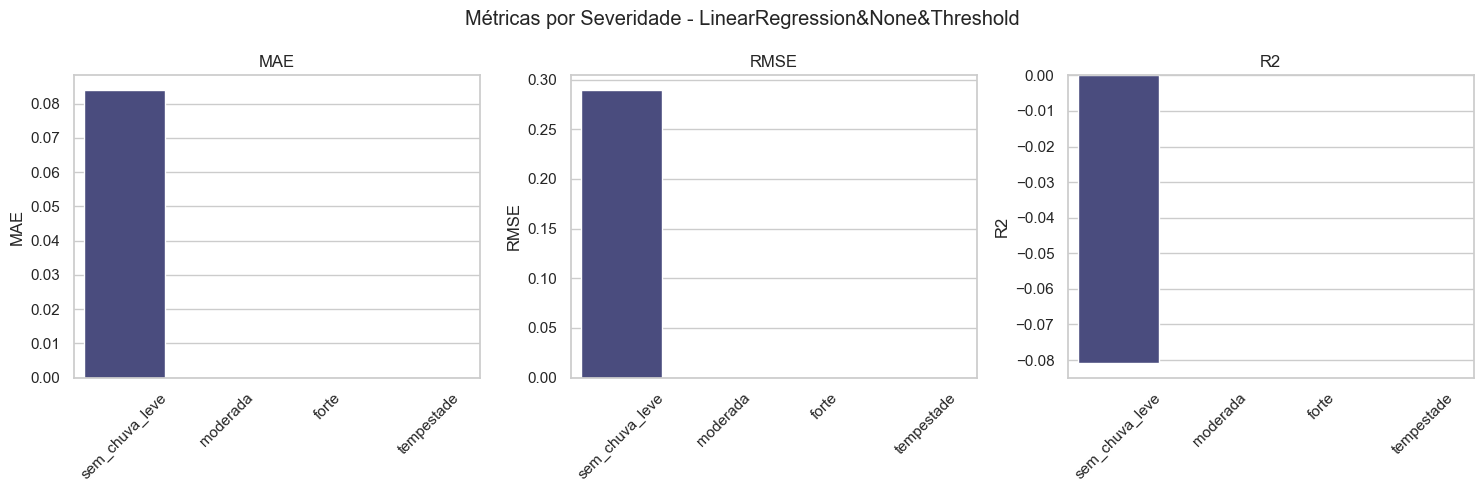

Modelo: LinearRegression&None&Threshold, RMSE: 0.2897, R2: -0.0809

Rodando: Modelo=DecisionTreeRegressor=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


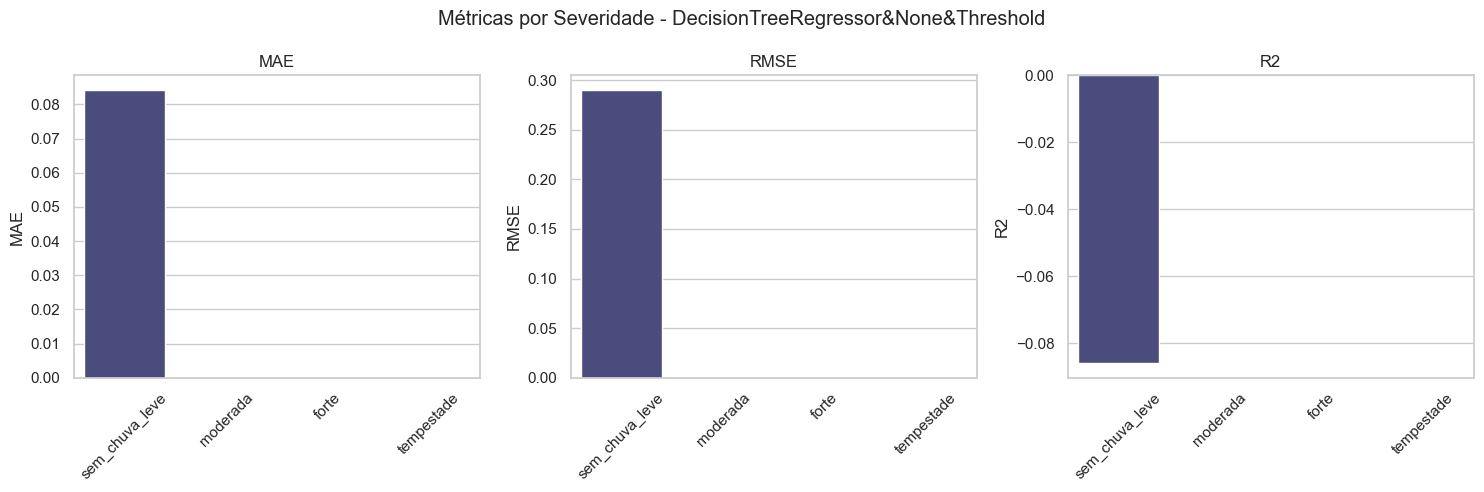

Modelo: DecisionTreeRegressor&None&Threshold, RMSE: 0.2904, R2: -0.0860

Rodando: Modelo=RandomForestRegressor=None Sampling=Threshold
Modelo de regressão (R) treinado.


C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')
C:\Users\SS7B2647\AppData\Local\Temp\ipykernel_28384\3036036678.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=values, palette='viridis')


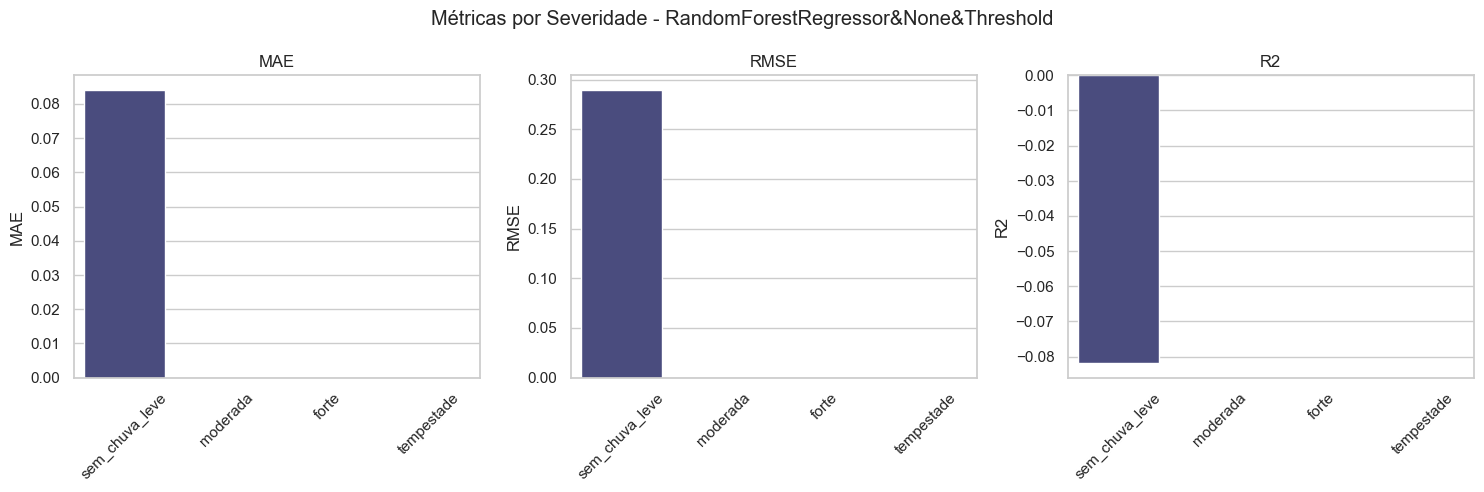

Modelo: RandomForestRegressor&None&Threshold, RMSE: 0.2898, R2: -0.0819


In [125]:

final_results = []
for model_config in model_regression:
    model_class_name = model_config['class_name']
    
    for sampling_config in sampling_configs:
        sampling_name = sampling_config['sampling_name']
        # Se não houver iteração de parâmetros, usamos [None]
        for param_reg in model_config.get('parameter_range', [None]):
            print(f"\nRodando: Modelo={model_class_name}"
                  f"={param_reg} Sampling={sampling_name}")
            
            # Para relatório, definimos um identificador:
            # set_name = f"{model_class_name}&{model_config.get('tuning_parameter','')}&{param_reg}&{sampling_name}"
            set_name = f"{model_class_name}&{param_reg}&{sampling_name}"
            
            # Preparar os parâmetros do modelo de regressão
            model_params_R = model_config['params'].copy()

            
            # Instanciar e treinar o modelo de regressão em (X_train_1, y_train_1)
            model_R = model_config['model_class'](**model_params_R)
            pipeline_R = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', model_R)
            ])
            pipeline_R.fit(X_train_1, y_train_1)
            print("Modelo de regressão (R) treinado.")
            
            # Obter as predições do regressor para os dados de teste
            # X_test (não processado) será utilizado; o pré-processador fará o escalonamento
            y_pred_reg = pipeline_R.predict(X_test)
            # Obter as predições do classificador C para os mesmos dados de teste
            y_pred_class = pipeline_C.predict(X_test)
            # Combinar os resultados: se o classificador prever 0, a predição final é 0; senão, usa a predição do regressor.
            y_pred_final = np.where(y_pred_class == 0, 0, y_pred_reg)
            
            # Para avaliação, compare y_pred_final com os valores contínuos reais do teste (y_test)
            mse = mean_squared_error(y_test, y_pred_final)
            mae = mean_absolute_error(y_test, y_pred_final)
            rmse = np.sqrt(mse)
            r2   = r2_score(y_test, y_pred_final)
            
            # Criar um relatório de métricas por severidade
            severity_report = report_severity_metrics(y_test, y_pred_final)
            
            final_results.append({
                "Model": set_name,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "Severity_Report": severity_report
            })
            plot_severity_metrics(severity_report, set_name )
            print(f"Modelo: {set_name}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
 

In [64]:
 
# Converter os resultados finais para DataFrame e exibir
df_final_results = pd.DataFrame(final_results)
print("\nResultados finais dos modelos de regressão (modelo híbrido):")
print(df_final_results)

# =============================================================================
# Seleção do melhor modelo (por exemplo, o com menor RMSE)
# =============================================================================
best_model_result = df_final_results.loc[df_final_results['RMSE'].idxmin()]
print("\nMelhor modelo selecionado:")
print(best_model_result)


# results_json_path = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'final_results.json')
# df_final_results.to_json(results_json_path, orient='records', lines=True)

end_time = time.time()
print(f"\nTempo total de execução: {end_time - start_time:.2f} segundos")


Resultados finais dos modelos de regressão (modelo híbrido):
                                  Model       MAE       MSE      RMSE  \
0       LinearRegression&None&Threshold  0.084053  0.083931  0.289708   
1  DecisionTreeRegressor&None&Threshold  0.084325  0.084325  0.290387   
2  RandomForestRegressor&None&Threshold  0.084171  0.084008  0.289841   

         R2                                    Severity_Report  
0 -0.080918  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  
1 -0.085993  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  
2 -0.081910  {'sem_chuva_leve': {'count': 9582, 'MAE': 0.08...  

Melhor modelo selecionado:
Model                                LinearRegression&None&Threshold
MAE                                                         0.084053
MSE                                                         0.083931
RMSE                                                        0.289708
R2                                                         -0.080918
Severity_Rep

# (5) Calibração de modelos

In [126]:
# Start timing
start_time = time.time()

In [127]:

# ===========================
# DATA LOADING AND PREPROCESSING
# ===========================
# Define column names
column_names = ["Education", "Dependents", "Income", "PropertyType", "AssetValue", "Installments", "InstallmentValue", "Phone", "Age", "ResidenceMonths", "DownPayment", "Target"]
categorical_columns = ["Education", "Dependents", "PropertyType", "Phone"]  
numerical_columns = ["Income", "AssetValue", "Installments", "InstallmentValue", "Age", "ResidenceMonths", "DownPayment"]
target_column = "Target"  

# Load training and testing data
try:
    df_train = pd.read_csv('credtrain.txt', sep='\t', header=None)
    df_test = pd.read_csv('credtest.txt', sep='\t', header=None)
except FileNotFoundError:
    base_path = os.path.dirname(os.path.realpath(__file__))
    df_train = pd.read_csv(os.path.join(base_path, 'credtrain.txt'), sep='\t', header=None)
    df_test = pd.read_csv(os.path.join(base_path, 'credtest.txt'), sep='\t', header=None)

df_train.columns = column_names
df_test.columns = column_names


In [128]:
# Separate features and target
X_test, y_test = df_test.drop(target_column, axis=1), df_test[target_column]
X_train, y_train = df_train.drop(target_column, axis=1), df_train[target_column]

# Additional split: training and validation
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, train_size=.5)
df_train_split = pd.DataFrame(X_train_split, columns=column_names[:-1])
df_train_split[target_column] = y_train_split

df_val = pd.DataFrame(X_val, columns=column_names[:-1])
df_val[target_column] = y_val


In [129]:
# Create preprocessor using ColumnTransformer:
# - OneHotEncoder for categorical columns.
# - StandardScaler for numerical columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)

# Fit the preprocessor with training data (features only) and apply it to partitions
X_train_split_transformed = preprocessor.fit_transform(X_train_split)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Define model configurations; include tuning keys for models that require parameter tuning.
model_configurations = [
    {
        'class_name': "KNeighborsClassifier",
        'model_class': KNeighborsClassifier
    },
    {
        'class_name': "LogisticRegression",
        'model_class': LogisticRegression
    },
    {
        'class_name': "GradientBoostingClassifier",
        'model_class': GradientBoostingClassifier,
    }
]

calibration_methods = [
    {
        'calibration_name': "CalibClassCV_Prefit",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit'}
    },
    {
        'calibration_name': "CalibClassCV_5Fold",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 5}
    },
    {
        'calibration_name': "CalibClassCV_Prefit_Isotonic",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit',  'method': 'isotonic'}
    },
    {
        'calibration_name': "CalibClassCV_Prefit_Sigmoid",
        'calibration_class': CalibratedClassifierCV,
        'params': {'cv': 'prefit', 'method': 'sigmoid'}
    },
    {
        'calibration_name': "None",
        'calibration_class': None,
    },
]

Processing model: KNeighborsClassifier


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit': 0.6685 | Young: 0.7232
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit': 0.6685 | Young: 0.7232


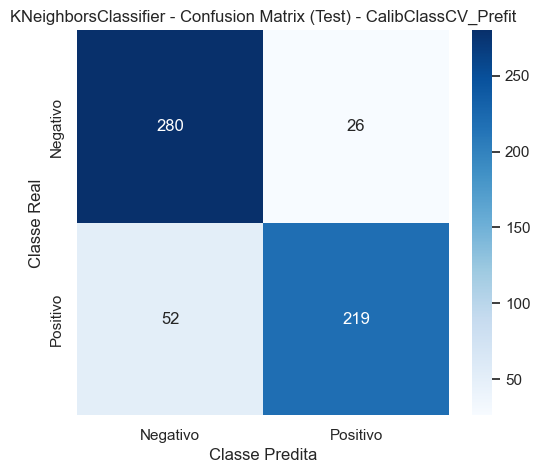

Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_5Fold': 0.4976 | Young: 0.7020
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_5Fold': 0.7313 | Young: 0.7295


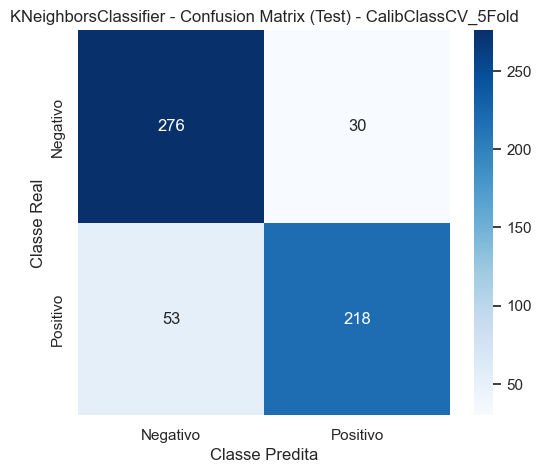

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.4909 | Young: 0.7232
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.4909 | Young: 0.7232


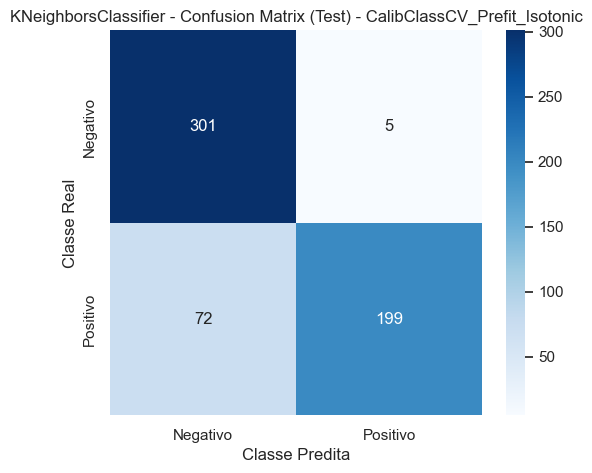

Best threshold (Val) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.6685 | Young: 0.7232
Best threshold (Test) for KNeighborsClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.6685 | Young: 0.7232


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


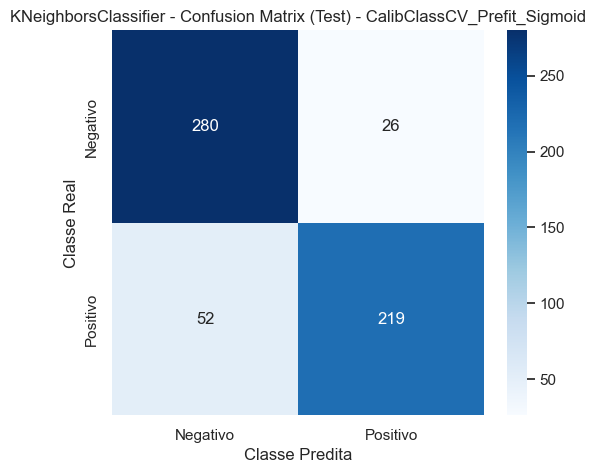

Best threshold (Val) for KNeighborsClassifier with calibration 'None': 0.6000 | Young: 0.7232
Best threshold (Test) for KNeighborsClassifier with calibration 'None': 0.6000 | Young: 0.7232


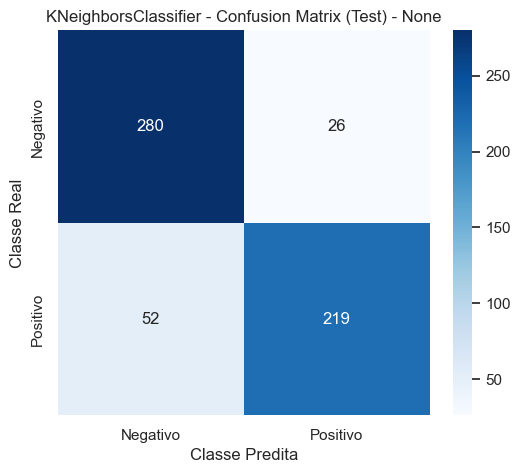

Best calibration for KNeighborsClassifier is: CalibClassCV_Prefit_Isotonic with Brier: 0.1137, ECE: 0.0000


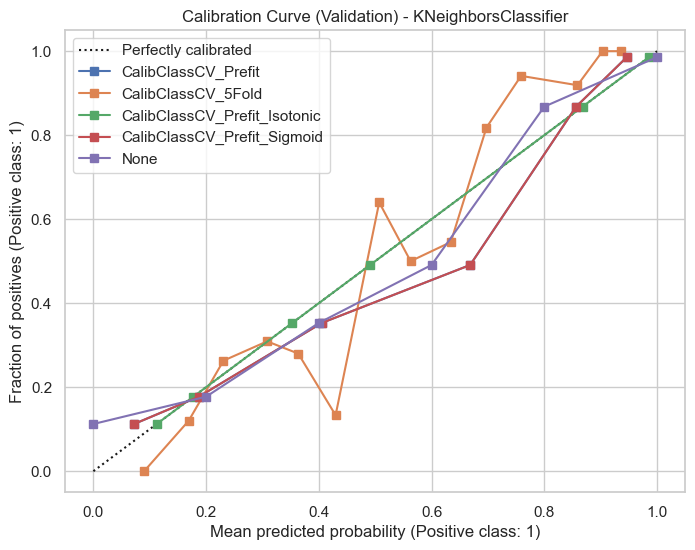

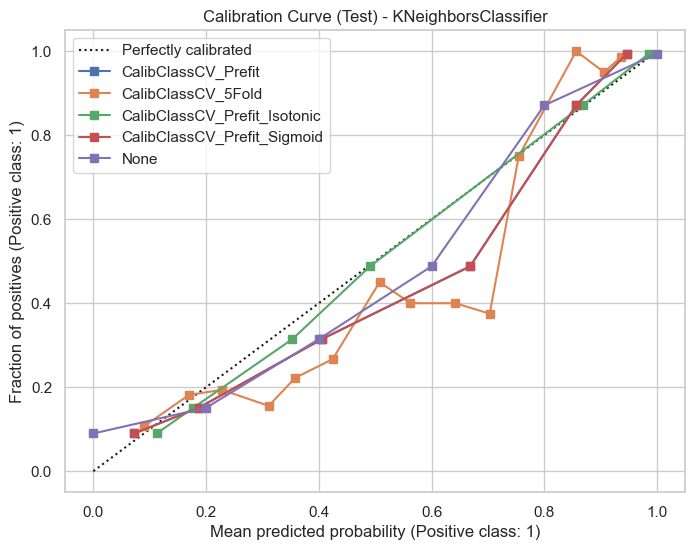

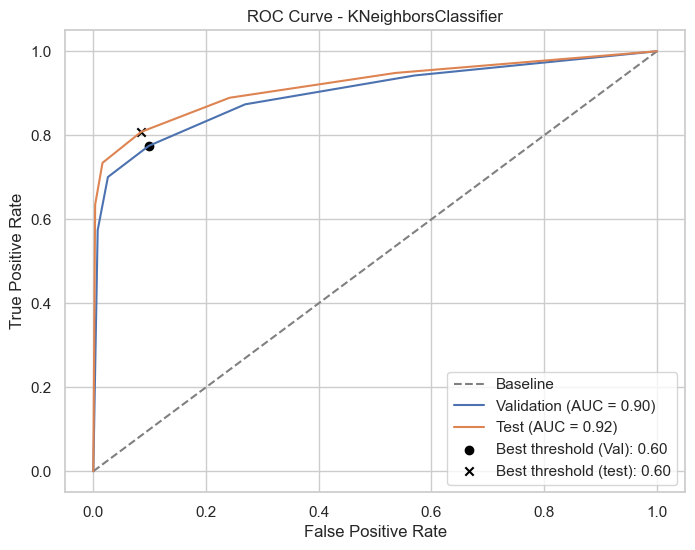

Processing model: LogisticRegression
Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit': 0.5370 | Young: 0.7008
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit': 0.5260 | Young: 0.7771


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


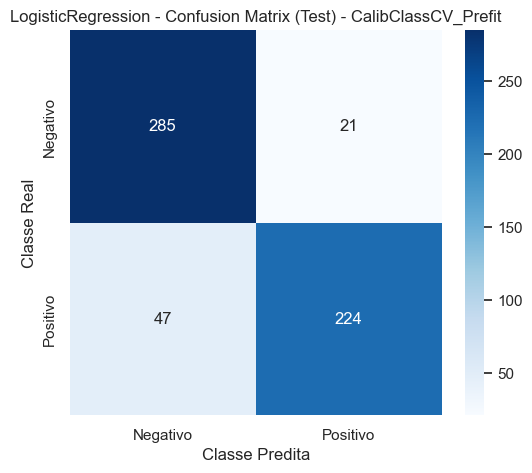

Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_5Fold': 0.4832 | Young: 0.6862
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_5Fold': 0.5601 | Young: 0.7848


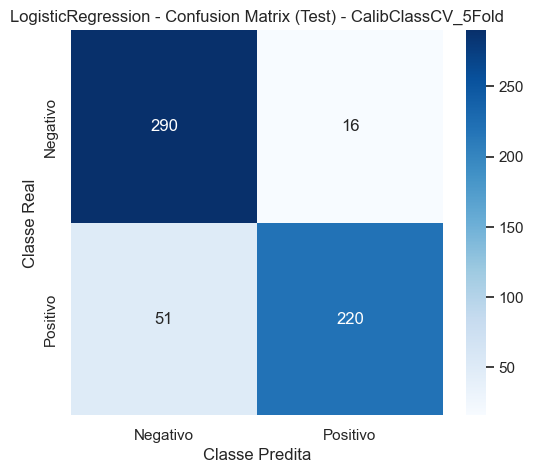

Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit_Isotonic': 0.6000 | Young: 0.6905
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit_Isotonic': 0.6000 | Young: 0.7726


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


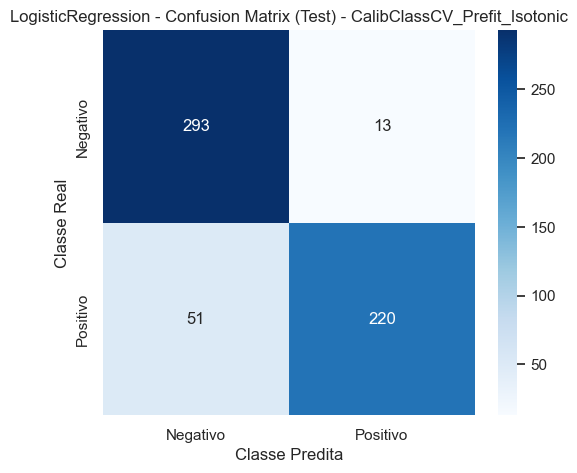

Best threshold (Val) for LogisticRegression with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5370 | Young: 0.7008
Best threshold (Test) for LogisticRegression with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5260 | Young: 0.7771


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


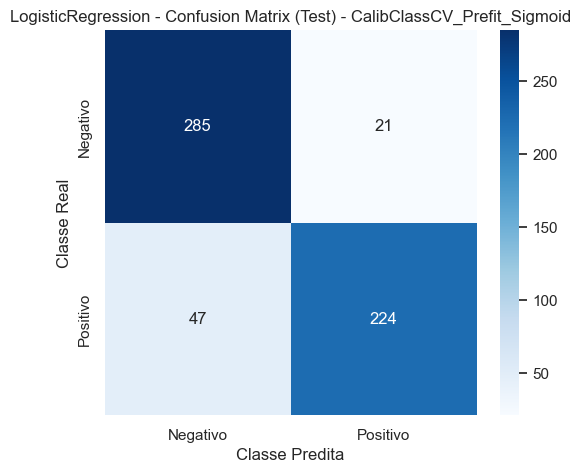

Best threshold (Val) for LogisticRegression with calibration 'None': 0.5179 | Young: 0.7008
Best threshold (Test) for LogisticRegression with calibration 'None': 0.5061 | Young: 0.7771


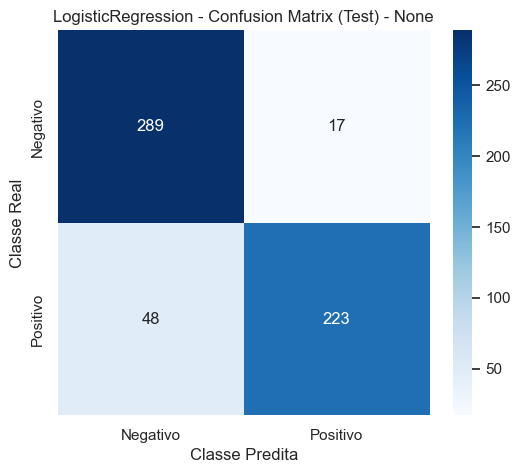

Best calibration for LogisticRegression is: CalibClassCV_Prefit_Isotonic with Brier: 0.0874, ECE: 0.0000


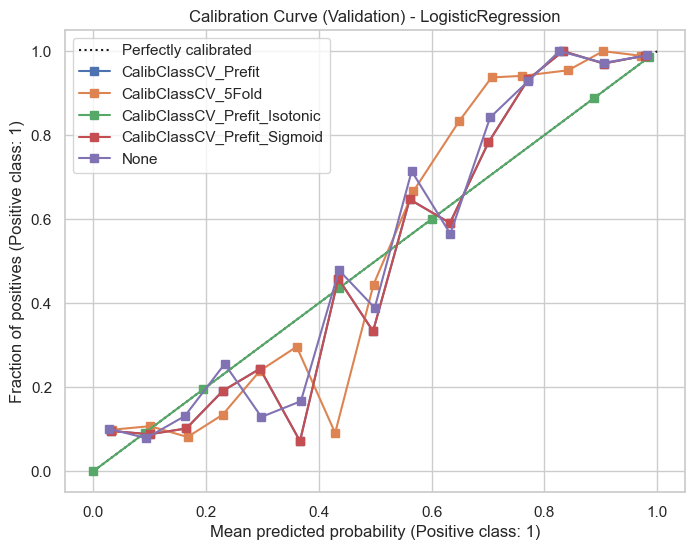

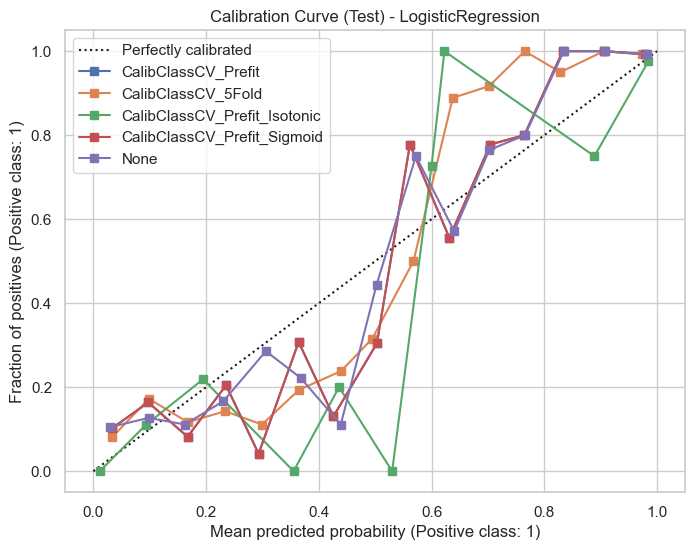

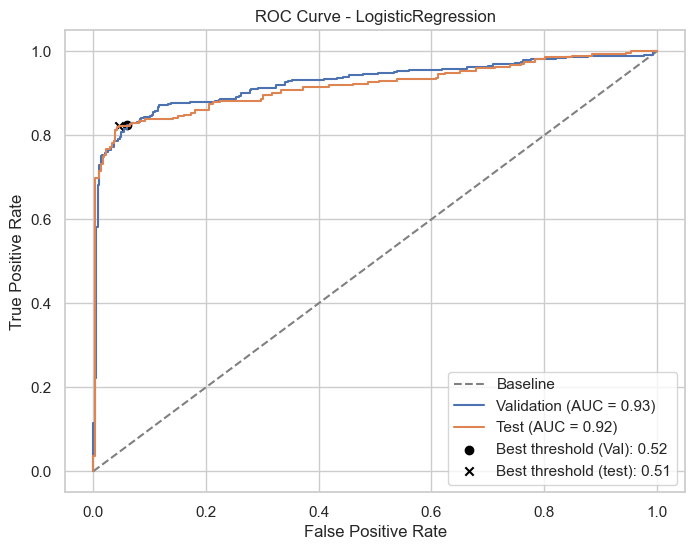

Processing model: GradientBoostingClassifier
Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit': 0.5600 | Young: 0.7062
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit': 0.6454 | Young: 0.7889


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


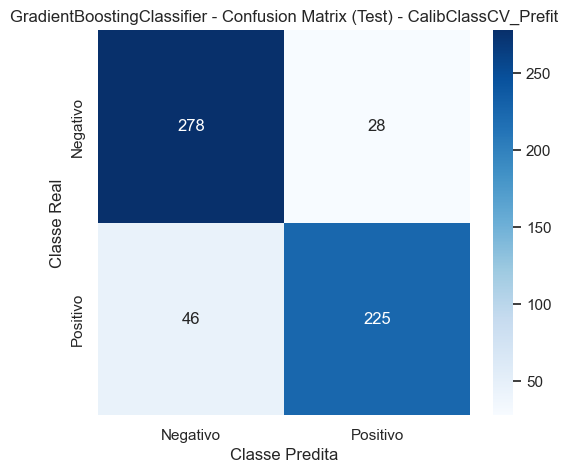

Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_5Fold': 0.3272 | Young: 0.7869
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_5Fold': 0.6155 | Young: 0.7950


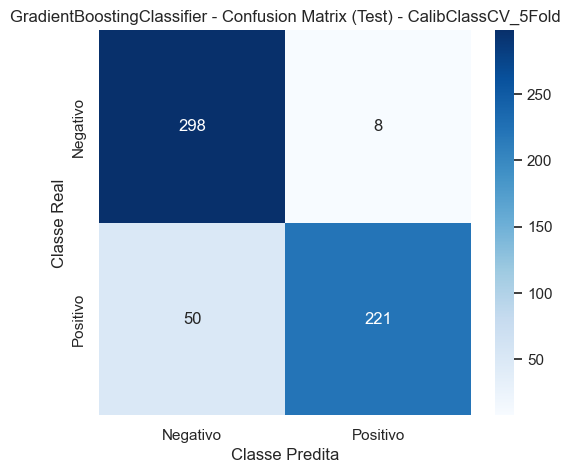

c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.6000 | Young: 0.7759
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Isotonic': 0.8000 | Young: 0.7824


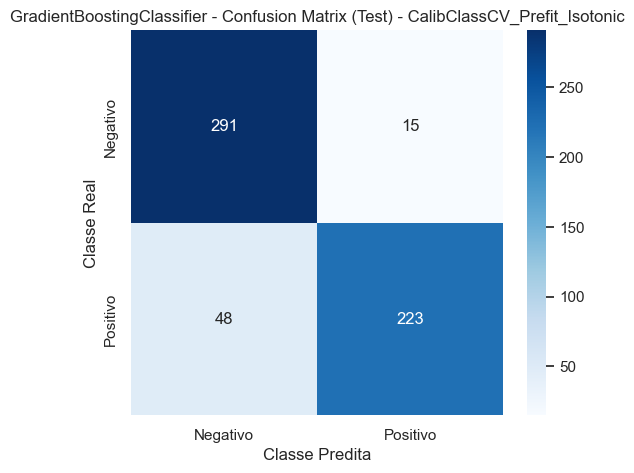

Best threshold (Val) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.5600 | Young: 0.7062
Best threshold (Test) for GradientBoostingClassifier with calibration 'CalibClassCV_Prefit_Sigmoid': 0.6454 | Young: 0.7889


c:\Users\SS7B2647\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


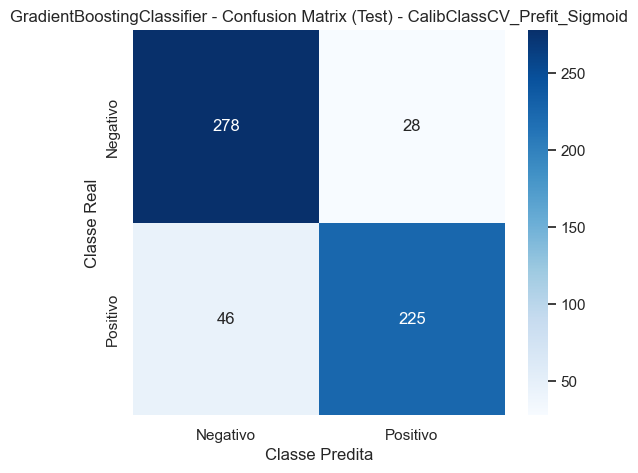

Best threshold (Val) for GradientBoostingClassifier with calibration 'None': 0.5502 | Young: 0.7062
Best threshold (Test) for GradientBoostingClassifier with calibration 'None': 0.6482 | Young: 0.7889


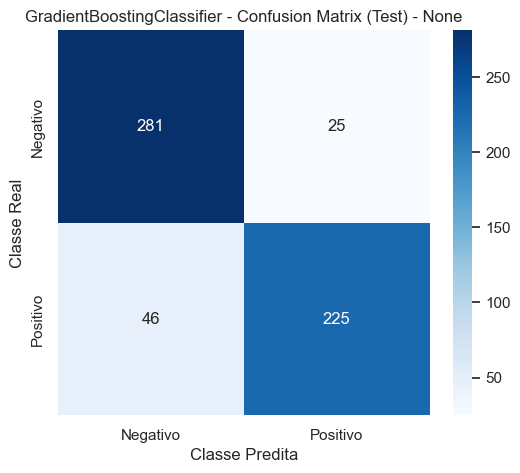

Best calibration for GradientBoostingClassifier is: CalibClassCV_Prefit_Isotonic with Brier: 0.0786, ECE: 0.0000


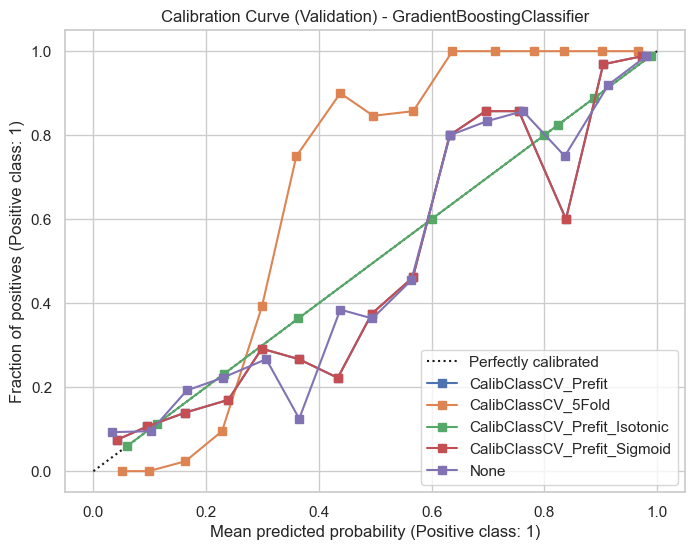

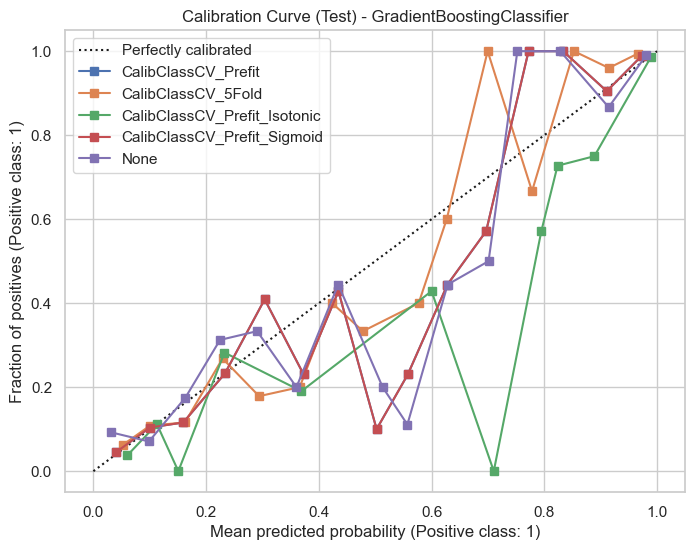

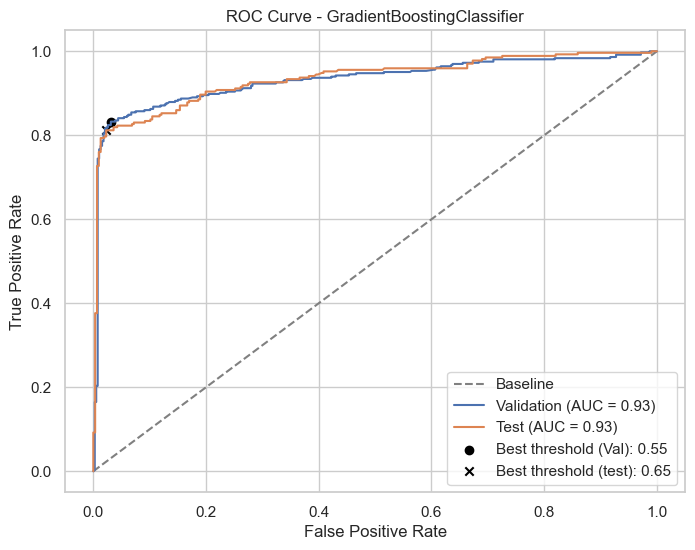

In [ ]:
results = []
# Lists to accumulate calibration curves for joint plotting (validation and test)
calibration_curves_val = []
calibration_curves_test = []

# Iterate through all models defined in model_configurations
for config in model_configurations:
    model_class_name = config['class_name']
    print(f"Processing model: {model_class_name}")
    
    # Create classifier pipeline with preprocessor
    clf = config['model_class']()
    pipeline_clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    # Train the pipeline using training data (split)
    pipeline_clf.fit(X_train_split, y_train_split)
    
    # List to store calibration results for this model
    model_calibration_results = []
    
    # For each calibration configuration, fit or use the model without calibration
    for calib in calibration_methods:
        calib_name = calib['calibration_name']
        if calib['calibration_class'] is not None:
            # Instantiate the calibrator with the 'estimator' parameter
            calibrator = calib["calibration_class"](estimator=pipeline_clf, **calib["params"])
            # Calibrate using validation data
            calibrator.fit(X_val, y_val)
            used_model = calibrator
        else:
            used_model = pipeline_clf

        # Get predictions and probabilities for validation and test
        y_pred_val   = used_model.predict(X_val)
        y_proba_val  = used_model.predict_proba(X_val)[:, 1]
        y_pred_test  = used_model.predict(X_test)
        y_proba_test = used_model.predict_proba(X_test)[:, 1]
        
        # Calculate ROC curves and ROC AUC
        fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_proba_val)
        roc_auc_val = roc_auc_score(y_val, y_proba_val)
        
        closest_val = np.sqrt(fpr_val**2 + (1 - tpr_val)**2)
        gmeans_val = np.sqrt(tpr_val * (1 - fpr_val))
        young_val = tpr_val + (1 - fpr_val) - 1

        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)
        roc_auc_test = roc_auc_score(y_test, y_proba_test)
        
        closest_test = np.sqrt(fpr_test**2 + (1 - tpr_test)**2)
        gmeans_test = np.sqrt(tpr_test * (1 - fpr_test))
        young_test = tpr_test + (1 - fpr_test) - 1
        
        # Determine the best threshold on the youg
        ix_val = np.argmax(young_val)
        best_threshold_val = thresholds_val[ix_val]
        print(f"Best threshold (Val) for {model_class_name} with calibration '{calib_name}': {best_threshold_val:.4f} | Young: {young_test[ix_val]:.4f}")
        
        ix_test = np.argmax(young_test)
        best_threshold_test = thresholds_test[ix_test]
        print(f"Best threshold (Test) for {model_class_name} with calibration '{calib_name}': {best_threshold_test:.4f} | Young: {young_test[ix_test]:.4f}")
        
        # Plot confusion matrix for the test set (fixed threshold 0.5)
        cm = confusion_matrix(y_test, (y_proba_test >= 0.5).astype(int))
        tn, fp, fn, tp = cm.ravel()
        plot_confusion_matrix_from_values(tp, tn, fp, fn, title=f"{model_class_name} - Confusion Matrix (Test) - {calib_name}")
        
        # Accumulate data (labels and probabilities) for calibration curve plotting
        calibration_curves_val.append((y_val, y_proba_val, calib_name))
        calibration_curves_test.append((y_test, y_proba_test, calib_name))
        
        # Calculate performance metrics on the validation set
        accuracy  = accuracy_score(y_val, y_pred_val)
        precision = precision_score(y_val, y_pred_val, zero_division=0)
        recall    = recall_score(y_val, y_pred_val, zero_division=0)
        f1        = f1_score(y_val, y_pred_val, zero_division=0)
        
        # Calculate calibration metrics
        calibration_metrics = evaluate_calibration(y_val, y_proba_val, n_bins=15)
        
        result_item = {
            'class_name': model_class_name,
            'calibration': calib_name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc_val': roc_auc_val,
            'roc_auc_test': roc_auc_test,
            'best_threshold': best_threshold_test,
        }
        # Merge calibration metrics into the result dictionary
        result_item.update(calibration_metrics)
        results.append(result_item)
        model_calibration_results.append(result_item)
    
    # Select the best calibration configuration for this model
    best_calibration_for_model = select_best_calibration(model_calibration_results)
    print(f"Best calibration for {model_class_name} is: {best_calibration_for_model['calibration']} with Brier: {best_calibration_for_model['Brier Score']:.4f}, ECE: {best_calibration_for_model['ECE']:.4f}")
    
    # --- Joint plotting of calibration curves for this model ---
    plt.figure(figsize=(8, 6))
    ax_val = plt.gca()
    
    for (y_true_val, y_prob_val, label_cal) in calibration_curves_val:
        disp = CalibrationDisplay.from_predictions(y_true_val, y_prob_val, n_bins=15, ax=ax_val, label=label_cal)
    ax_val.set_title(f"Calibration Curve (Validation) - {model_class_name}")
    ax_val.legend(loc="best")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 6))
    ax_test = plt.gca()
    
    for (y_true_test, y_prob_test, label_cal) in calibration_curves_test:
        disp = CalibrationDisplay.from_predictions(y_true_test, y_prob_test, n_bins=15, ax=ax_test, label=label_cal)
    ax_test.set_title(f"Calibration Curve (Test) - {model_class_name}")
    ax_test.legend(loc="best")
    plt.grid(True)
    plt.show()
    
    # Plot ROC curves for validation and test
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')
    plt.plot(fpr_val, tpr_val, label=f"Validation (AUC = {roc_auc_val:.2f})")
    plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {roc_auc_test:.2f})")
    plt.scatter(fpr_val[ix_val], tpr_val[ix_val], marker='o', color='black', label=f"Best threshold (Val): {best_threshold_val:.2f}")
    plt.scatter(fpr_test[ix_test], tpr_test[ix_test], marker='x', color='black', label=f"Best threshold (test): {best_threshold_test:.2f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_class_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Clear lists for the next model
    calibration_curves_val.clear()
    calibration_curves_test.clear()

In [131]:

# Display overall results in a DataFrame
df_results = pd.DataFrame(results)
print(df_results)

# Select the best overall model based on test ROC AUC
best_model = max(results, key=lambda item: item['roc_auc_test'])
calibration_str = (f"Calibration: {best_model['calibration']}" if best_model['calibration'] != "None" else "No calibration")

print("------------------------------------------------------")
print("Best identified model:")
print(f"Model: {best_model['class_name']} / {calibration_str}")
print(f"Accuracy (Validation): {best_model['accuracy']:.4f}")
print(f"Precision (Validation): {best_model['precision']:.4f}")
print(f"Recall (Validation): {best_model['recall']:.4f}")
print(f"F1 Score (Validation): {best_model['f1']:.4f}")
print(f"ROC AUC (Validation): {best_model['roc_auc_val']:.4f}")
print(f"ROC AUC (Test): {best_model['roc_auc_test']:.4f}")
print(f"Brier Score: {best_model['Brier Score']:.4f}")
print(f"ECE: {best_model['ECE']:.4f}")
print(f"MCE: {best_model['MCE']:.4f}")

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.2f} seconds")

                    class_name                   calibration  accuracy  \
0         KNeighborsClassifier           CalibClassCV_Prefit  0.840000   
1         KNeighborsClassifier            CalibClassCV_5Fold  0.896000   
2         KNeighborsClassifier  CalibClassCV_Prefit_Isotonic  0.841333   
3         KNeighborsClassifier   CalibClassCV_Prefit_Sigmoid  0.840000   
4         KNeighborsClassifier                          None  0.840000   
5           LogisticRegression           CalibClassCV_Prefit  0.877333   
6           LogisticRegression            CalibClassCV_5Fold  0.901333   
7           LogisticRegression  CalibClassCV_Prefit_Isotonic  0.884000   
8           LogisticRegression   CalibClassCV_Prefit_Sigmoid  0.877333   
9           LogisticRegression                          None  0.881333   
10  GradientBoostingClassifier           CalibClassCV_Prefit  0.897333   
11  GradientBoostingClassifier            CalibClassCV_5Fold  0.942667   
12  GradientBoostingClassifier  CalibC

# (6) Validação cruzada aninhada

In [75]:
start_time = time.time()

In [76]:
# 1. Carrega e pré-processa dados
"""Carrega e pré-processa os dados"""
df_diamonds = df_diamonds

# Engenharia de features: Adiciona volume
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

target_column = 'price'
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]


In [77]:

# 2. Divide dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 3. Configura CV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)


In [78]:

# 4. Executa Nested CV
# =============================================
# 2. Definição do Pipeline e Espaços de Busca
# =============================================

"""Cria o pré-processador com codificação ordinal"""
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
categorical_features = ['cut', 'color', 'clarity']
# Define ordens das categorias
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor =  ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), 
            categorical_features)
    ])

model_configs = [
        {
            'name': "KNeighborsRegressor",
            'class': KNeighborsRegressor,
            'params': {
                'model__n_neighbors': randint(3, 20),
                'model__weights': ['uniform', 'distance'],
                'model__metric': ['euclidean', 'manhattan']
            },
            'random_state': False
        },
        {
            'name': "GradientBoostingRegressor",
            'class': GradientBoostingRegressor,
            'params': {
                'model__n_estimators': randint(100, 500),
                'model__learning_rate': uniform(0.01, 0.19),
                'model__max_depth': randint(3, 8),
                'model__subsample': uniform(0.6, 0.4)
            },
            'random_state': True
        }
    ]


In [ ]:

results = []

for config in model_configs:
    # Configuração do pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['class']())
    ])
    
    # Configuração da busca
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['params'],
        n_iter=20,
        cv=inner_cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    
    # Validação cruzada externa
    cv_scores = cross_val_score(
        search, X, y, 
        cv=outer_cv, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    # Armazena resultados
    rmse_scores = np.sqrt(-cv_scores)
    best_model = search.fit(X, y).best_estimator_
    
    results.append({
        'model': config['name'],
        'mean_rmse': rmse_scores.mean(),
        'std_rmse': rmse_scores.std(),
        'best_params': search.best_params_,
        'best_estimator': best_model
    })


In [ ]:

results_df = pd.DataFrame(results)
# 5. Seleciona e avalia o melhor modelo
best_model_info = results_df.loc[results_df['mean_rmse'].idxmin()]
best_model = best_model_info['best_estimator']


In [ ]:

# 6. Avaliação final no teste
y_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

# 7. Feature Importance
feature_names = (X_train.columns.tolist())
if 'GradientBoosting' in best_model_info['model']:
    importances = best_model.named_steps['model'].feature_importances_
else:
    importances = None


In [ ]:

# 8. Gera visualizações
model_evaluation(
    best_model_info['model'], 
    y_test, y_pred,
    feature_importances=importances
)

print(f"\nMelhor modelo: {best_model_info['model']}")
print(f"RMSE no teste: {test_rmse:.2f}")
print(f"R² no teste: {test_r2:.2f}")
print(f"Tempo total: {time.time()-start_time:.2f}s")

Best Model

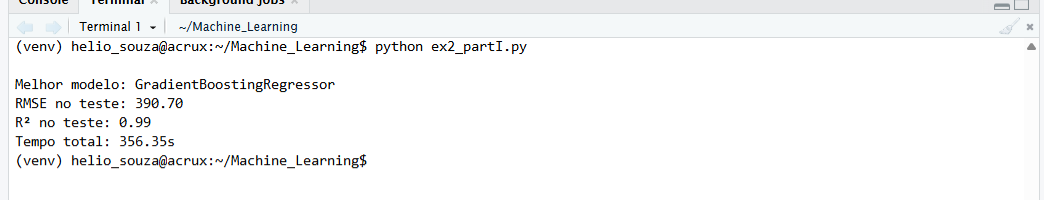

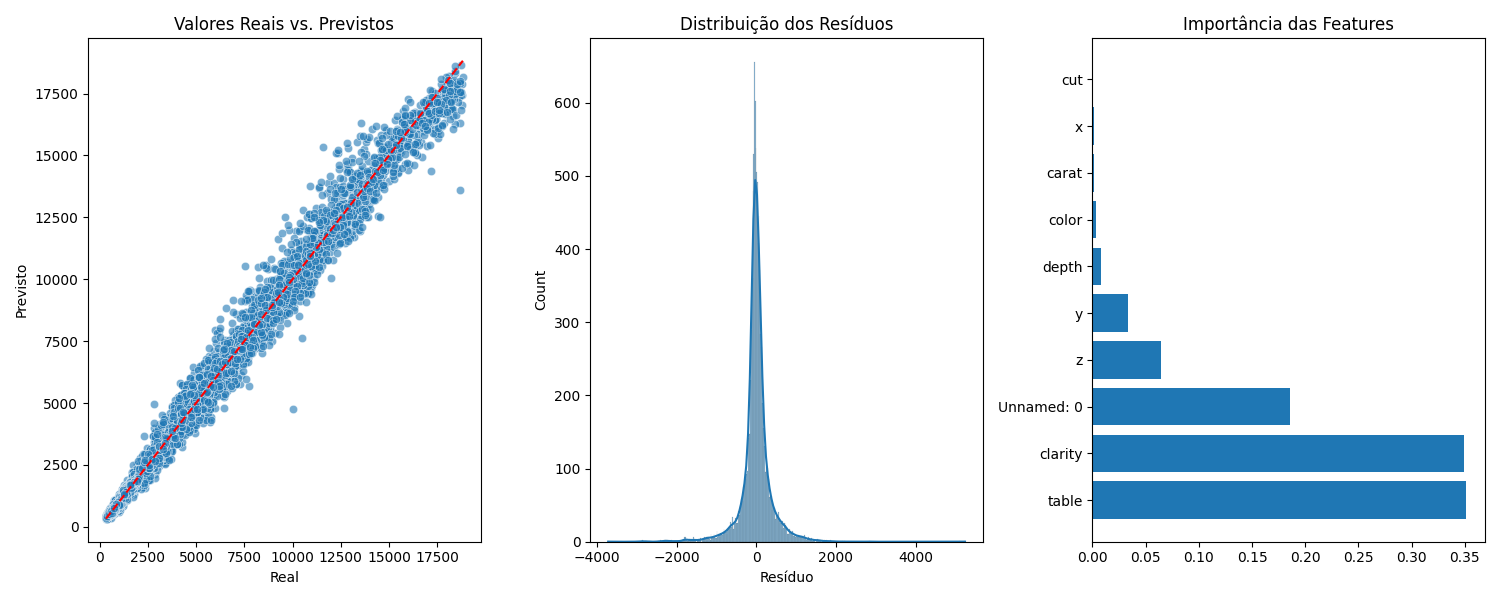